# E71 · Drift diffusion models: how people trade speed for accuracy, and what they should do

| | |
|---|---|
| **Type** | Advanced worked example - read, run, modify |
| **Data** | Real: **Wagenmakers, Ratcliff, Gomez & McKoon (2008)**, *Journal of Memory and Language* 58:140-159, Experiment 1, via the R package `rtdists` (`speed_acc`): 17 people, 31,522 lexical decisions ("is this string of letters a word?") under **speed** or **accuracy** instructions, with the choice and the response time of every trial |
| **You will learn** | The **drift diffusion model** (DDM) as noisy evidence accumulation to a threshold, and why it is the optimal sequential test (Wald's SPRT) · simulating it, and a continuity correction for Euler's first-passage bias · the **Wiener first-passage-time density** written by hand in PyTensor (Navarro-Fuss small- and large-time series), with **drift variability** integrated in closed form and **starting-point variability** by Gauss-Legendre quadrature · unit tests for a new likelihood (mass, closed forms, series truncation, quadrature, simulation, gradients) · a hierarchical DDM over 17 people as a `pm.CustomDist` on signed response times, with a fast-guess contaminant (and what a uniform one broke) · the classic failure: a plain DDM **cannot produce slow errors** · **quantile-probability plots** on held-out trials, PSIS-LOO and held-out log scores · what a speed instruction changes (threshold, non-decision time, drift) and **selective influence** · a **decision**: the threshold that maximises correct answers per minute (reward rate), per person, under posterior uncertainty |

## The setting

Every quick choice - is this a word, is that a stop sign, is this transaction fraud - is a small
decision under noisy evidence. You can answer fast and make more mistakes, or wait for more
evidence and be slower. People move along this **speed-accuracy trade-off** when told to, and a
good model of choices should explain *both* which answer they gave and *how long* it took.

The **drift diffusion model** (Ratcliff 1978) does exactly that. Evidence for "word" over
"nonword" accumulates over time as a random walk with an average rate (the **drift**, $v$); a
response is made when the total first reaches one of two thresholds a distance $a$ apart. The
walk starts at a fraction $w$ of the way between them (a **bias**), and a **non-decision time**
$t_0$ covers seeing the letters and pressing the key. Four parameters with a psychological
meaning each: quality of evidence, caution, bias, and everything else.

The DDM is also a *normative* model: it is the continuous-time version of Wald's **sequential
probability ratio test**, which among all tests reaching a given error rate needs the fewest
observations on average (Wald & Wolfowitz 1948; Bogacz et al. 2006). So once we have measured
someone's evidence quality, we can ask a decision question of our own: **which threshold should
they use?** If each correct answer is worth the same and time is what you spend, the best
threshold maximises the **reward rate**, correct answers per second. We will estimate it for
every participant, with its uncertainty, and see whether the speed or the accuracy instruction
came closer.

**The experiment.** In Wagenmakers et al.'s (2008) Experiment 1, participants saw strings of
letters and pressed one key for "word" and another for "nonword". Words were of high, low or
very low frequency in English; nonwords were made by changing letters of such words. Blocks
alternated between two instructions: in *accuracy* blocks "ERROR" appeared after mistakes, and
in *speed* blocks "TOO SLOW" appeared after any response slower than 0.75 s. The `rtdists`
version has the 15 participants of the paper and two more analysed by Heathcote & Love (2012).

| part | question | tool |
|---|---|---|
| A | What does the model say about speed and accuracy? | simulation, closed forms |
| B | What is the likelihood of one choice and its time? | Wiener first-passage density, unit tests |
| C | Does a plain DDM fit the data? | hierarchical DDM, error vs correct response times |
| D | What does it take to fit? | drift and starting-point variability, held-out checks, LOO |
| E | What does "be fast" change in the mind? | threshold, non-decision time, drift |
| F | Which threshold should each person use? | reward rate under the posterior |

In [1]:
import logging
import time
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor
import pytensor.tensor as pt
import xarray as xr
from scipy import special

from pymc_challenges import data

RANDOM_SEED = 71
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
logging.getLogger("pymc").setLevel(logging.WARNING)
warnings.filterwarnings("ignore", category=RuntimeWarning, module="arviz")
pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 20)
BLUE, ORANGE, AQUA, GREY, PURPLE, RED = "#2a78d6", "#eb6834", "#1baf7a", "#8a8a86", "#8c5ac8", "#c8384e"
JAX = {"backend": "jax", "gradient_backend": "jax"}  # see part C for why the JAX backend
print(f"PyMC {pm.__version__}, ArviZ {az.__version__}, PyTensor {pytensor.__version__}")

PyMC 6.3.2, ArviZ 1.3.0, PyTensor 3.3.2


## A. The model: a random walk to one of two thresholds

In scaled units (the noise has standard deviation 1 per second, the convention of Navarro & Fuss
2009 and HDDM; Ratcliff's papers use 0.1, so divide our $a$ and $v$ by 10 to compare) the
evidence $x(t)$ starts at $a w$ and moves as

$$dx = v\,dt + dW, \qquad \text{respond "word" when } x = a, \quad \text{"nonword" when } x = 0,$$

and the response time is the first-passage time plus $t_0$. For an unbiased start ($w = 1/2$)
two classic results give the whole trade-off (e.g. Bogacz et al. 2006):

$$P(\text{correct}) = \frac{1}{1 + e^{-v a}}, \qquad
  E[\text{decision time}] = \frac{a}{2v}\tanh\!\left(\frac{v a}{2}\right).$$

Raising the threshold $a$ buys accuracy with time; better evidence (larger $v$) buys both.

A simulator is useful for building intuition and, later, for testing the likelihood. The plain
Euler scheme checks for a crossing only every $\Delta t$, so it misses walks that cross and come
back between steps: its thresholds are effectively *wider*, and it reports too many correct
answers and too-slow times. Moving each threshold inwards by $0.5826\sqrt{\Delta t}$ removes most
of this bias (Broadie, Glasserman & Kou 1997).

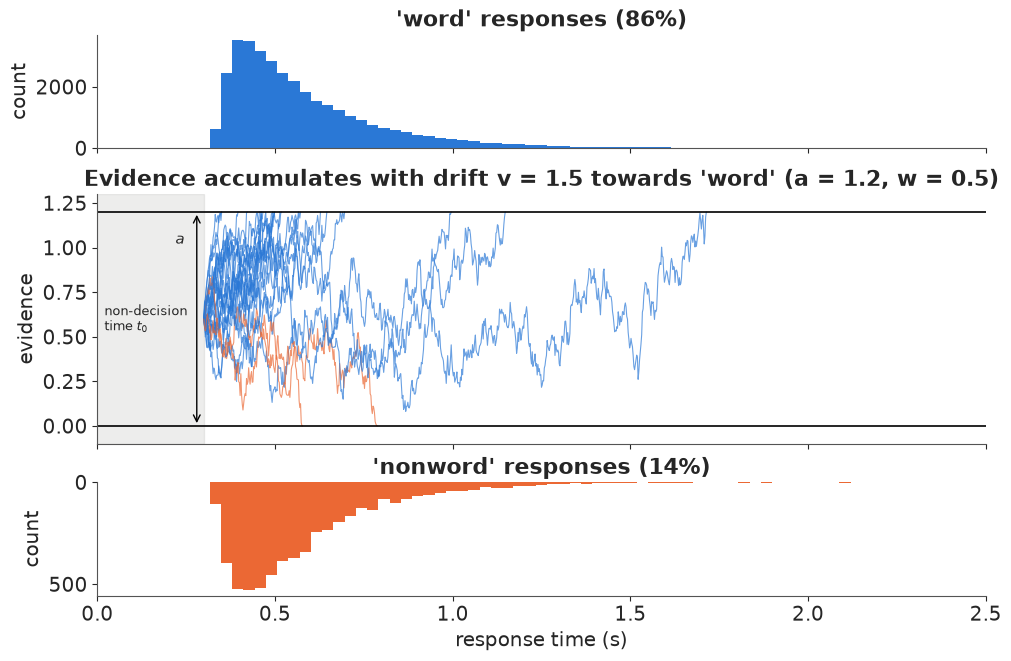

In [2]:
def simulate_ddm(v, a, w, t0, n, rng, sv=0.0, sz=0.0, dt=1e-3, t_max=6.0, correct_bias=True):
    """Euler simulation of the DDM. Parameters may be scalars or length-n arrays.

    Drift ~ N(v, sv) per trial; start uniform on a * (w +- sz / 2). Returns response times
    (NaN if no threshold is reached by t_max) and whether the upper threshold was hit."""
    v, a, w, t0, sv, sz = (np.broadcast_to(np.asarray(p, float), (n,)) for p in (v, a, w, t0, sv, sz))
    drift = v + sv * rng.standard_normal(n)
    x = a * (w + sz * (rng.random(n) - 0.5))
    shift = 0.5826 * np.sqrt(dt) if correct_bias else 0.0
    rt, upper, alive = np.full(n, np.nan), np.zeros(n, bool), np.arange(n)
    for step in range(1, int(t_max / dt) + 1):
        x[alive] += drift[alive] * dt + np.sqrt(dt) * rng.standard_normal(alive.size)
        up, down = x[alive] >= a[alive] - shift, x[alive] <= shift
        rt[alive[up | down]] = step * dt + t0[alive[up | down]]
        upper[alive[up]] = True
        alive = alive[~(up | down)]
        if alive.size == 0:
            break
    return rt, upper


# a few paths for the picture, with the same scheme
V0, A0, W0, T00 = 1.5, 1.2, 0.5, 0.3
fig, axes = plt.subplots(3, 1, figsize=(10, 6.5), height_ratios=[1, 2.2, 1], sharex=True)
path_rng = np.random.default_rng(3)
dt = 2e-3
for i in range(24):
    x, xs = A0 * W0, [A0 * W0]
    while 0 < x < A0 and len(xs) < 2000:
        x += V0 * dt + np.sqrt(dt) * path_rng.standard_normal()
        xs.append(min(max(x, 0), A0))
    tt = T00 + dt * np.arange(len(xs))
    axes[1].plot(tt, xs, color=BLUE if xs[-1] >= A0 else ORANGE, lw=0.8, alpha=0.7)
axes[1].axhline(A0, color="k", lw=1.2)
axes[1].axhline(0, color="k", lw=1.2)
axes[1].axvspan(0, T00, color=GREY, alpha=0.15)
axes[1].text(0.02, A0 * 0.5, "non-decision\ntime $t_0$", fontsize=9, va="center")
axes[1].annotate("", xy=(0.28, A0), xytext=(0.28, 0), arrowprops=dict(arrowstyle="<->"))
axes[1].text(0.22, A0 * 0.85, "$a$", fontsize=11)
axes[1].set(ylabel="evidence", ylim=(-0.1, A0 + 0.1))
axes[1].set_title(f"Evidence accumulates with drift v = {V0} towards 'word' (a = {A0}, w = {W0})")
rt_sim, up_sim = simulate_ddm(V0, A0, W0, T00, 40_000, np.random.default_rng(1))
bins = np.linspace(0, 2.5, 80)
axes[0].hist(rt_sim[up_sim], bins=bins, color=BLUE)
axes[0].set(ylabel="count", title=f"'word' responses ({up_sim.mean():.0%})")
axes[2].hist(rt_sim[~up_sim], bins=bins, color=ORANGE)
axes[2].invert_yaxis()
axes[2].set(ylabel="count", xlabel="response time (s)", title=f"'nonword' responses ({1 - up_sim.mean():.0%})")
axes[2].set_xlim(0, 2.5);

The response-time distributions are right-skewed, as real ones are, and - a feature to remember
- with an unbiased start the *errors* (orange) have exactly the same time distribution as the
correct responses, only fewer of them.

Next, the speed-accuracy trade-off from the closed forms, with simulated points as a check, and
what happens without the continuity correction.

     a  corrected  P exact  P sim  RT exact  RT sim
0  0.6       True    0.769  0.770     0.381   0.382
1  0.6      False    0.769  0.802     0.381   0.403
2  1.2       True    0.917  0.913     0.550   0.550
3  1.2      False    0.917  0.928     0.550   0.576
4  2.0       True    0.982  0.983     0.782   0.785
5  2.0      False    0.982  0.984     0.782   0.805


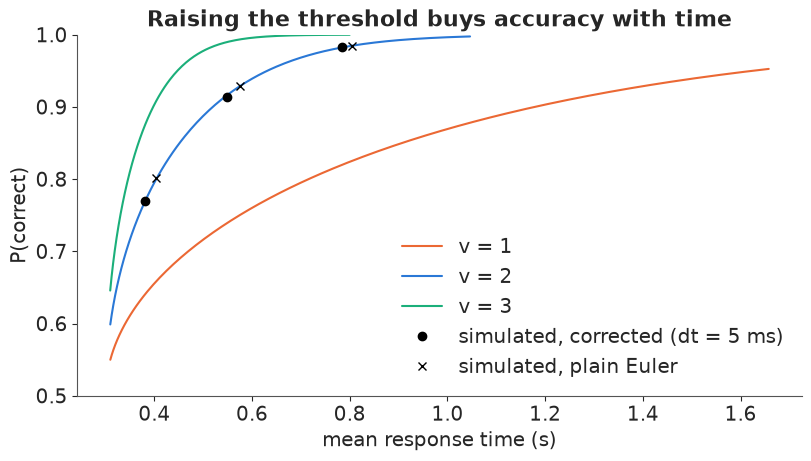

In [3]:
def tradeoff(v, a):
    """P(correct) and mean decision time for an unbiased start (w = 1/2)."""
    v = np.where(np.abs(v) < 1e-9, 1e-9, v)
    return special.expit(v * a), a / (2 * v) * np.tanh(v * a / 2)


fig, ax = plt.subplots(figsize=(8, 4.5))
a_grid = np.linspace(0.2, 3.0, 200)
for v, col in [(1.0, ORANGE), (2.0, BLUE), (3.0, AQUA)]:
    pc, dt_mean = tradeoff(v, a_grid)
    ax.plot(dt_mean + T00, pc, color=col, label=f"v = {v:g}")
rows = []
for a_ in (0.6, 1.2, 2.0):
    pc, dt_mean = tradeoff(2.0, a_)
    for corr, mk in [(True, "o"), (False, "x")]:
        rt_, up_ = simulate_ddm(2.0, a_, 0.5, T00, 20_000, np.random.default_rng(7), dt=5e-3,
                                correct_bias=corr)
        ax.plot(np.nanmean(rt_), up_.mean(), mk, color="k", ms=6)
        rows.append((a_, corr, pc, up_.mean(), dt_mean + T00, np.nanmean(rt_)))
ax.plot([], [], "ok", label="simulated, corrected (dt = 5 ms)")
ax.plot([], [], "xk", label="simulated, plain Euler")
ax.set(xlabel="mean response time (s)", ylabel="P(correct)", ylim=(0.5, 1.0),
       title="Raising the threshold buys accuracy with time")
ax.legend(loc="lower right")
print(pd.DataFrame(rows, columns=["a", "corrected", "P exact", "P sim", "RT exact", "RT sim"]).round(3));

With a coarse 5 ms step the plain Euler walk overstates accuracy and response times, while the
corrected walk sits on the exact curves. We use the correction (and a 1 ms step) from now on.

## B. The likelihood of one choice and its time

To fit the model we need the joint density of the response time *and* which threshold was hit.
For the lower threshold, drift $v$, separation $a$ and start $w$, the first-passage density at
decision time $t$ is (Feller; Navarro & Fuss 2009)

$$p(t, \text{lower} \mid v, a, w) = \frac{1}{a^2}\, e^{-v a w - v^2 t / 2}\, f\!\left(\frac{t}{a^2} \,\middle|\, w\right),$$

where $f(u \mid w)$ is the density for a walk with no drift between thresholds at 0 and 1. It has
two infinite series; one converges fast at small $u$ and the other at large $u$:

$$f(u \mid w) = \frac{1}{\sqrt{2\pi u^3}} \sum_{k=-\infty}^{\infty} (w + 2k)\, e^{-(w + 2k)^2 / 2u}
  = \pi \sum_{k=1}^{\infty} k\, e^{-k^2 \pi^2 u / 2} \sin(k \pi w).$$

The upper threshold is the mirror image: replace $v \to -v$ and $w \to 1 - w$. Navarro & Fuss
give bounds on how many terms each series needs; we fix the numbers instead and **test** them. We
use the small-time series with $k = -2..2$ below $u = 0.5$ and two large-time terms above, which
keeps every term finite so the switch leaks no NaN gradients (both branches get a clipped copy
of $u$).

Two extensions make the model realistic (Ratcliff & McKoon 2008):

* **Drift variability** across trials, $v_{\text{trial}} \sim N(v, s_v^2)$. Some items are easier
  than others. The density is Gaussian in $v$ apart from the factor $f$, so the integral over $v$
  has a closed form (used in HDDM, Wiecki, Sofer & Frank 2013):
  $\frac{1}{a^2}\, f \cdot \exp\!\Big(\frac{(a w s_v)^2 - 2 a v w - v^2 t}{2(1 + s_v^2 t)}\Big) / \sqrt{1 + s_v^2 t}$.
* **Starting-point variability**, $w_{\text{trial}} \sim \text{Uniform}(w \pm s_z/2)$. Some trials
  start closer to one answer. There is no closed form, so we integrate with 3-point
  Gauss-Legendre quadrature and test that too.

In [4]:
GL_X, GL_W = np.polynomial.legendre.leggauss(3)
U_SWITCH = 0.5


def log_f01(u, w):
    """log first-passage density at the lower threshold for a zero-drift walk between 0 and 1,
    started at w, at time u. Small-time series (k = -2..2) below U_SWITCH, large-time (k = 1, 2)
    above; each branch sees a clipped u, so neither produces inf/NaN (or NaN gradients)."""
    us, ul = pt.minimum(u, U_SWITCH), pt.maximum(u, U_SWITCH)
    small_sum = w                                           # the k = 0 term, exponent factored out
    for k in (-2, -1, 1, 2):
        small_sum = small_sum + (w + 2 * k) * pt.exp(-2 * k * (w + k) / us)
    small = pt.log(small_sum) - w**2 / (2 * us) - 0.5 * np.log(2 * np.pi) - 1.5 * pt.log(us)
    s1 = pt.sin(np.pi * w)                                  # sin(2 pi w) = 2 sin cos
    large = (np.log(np.pi) - np.pi**2 * ul / 2
             + pt.log(s1 + 4 * s1 * pt.cos(np.pi * w) * pt.exp(-1.5 * np.pi**2 * ul)))
    return pt.switch(u < U_SWITCH, small, large)


def wfpt_logp(t, upper, v, a, w, sv, sz=None, gl=(GL_X, GL_W)):
    """log density of decision time t (> 0) at the upper (True) or lower threshold.

    v: drift towards the upper threshold; a: separation; w: relative start; sv: sd of the drift
    across trials (closed form); sz: width of the uniform start range, as a fraction of a
    (Gauss-Legendre nodes on a new last axis). All arguments broadcast."""
    vv = pt.switch(upper, -v, v)
    w = pt.switch(upper, 1 - w, w)
    if sz is not None:
        gx, gw = gl
        w = w[..., None] + 0.5 * pt.switch(upper, -1, 1)[..., None] * sz[..., None] * gx
        t, vv, a = t[..., None], vv[..., None], a[..., None]
        sv = pt.as_tensor_variable(sv)
        sv = sv[..., None] if sv.ndim else sv
    lp = (log_f01(t / a**2, w) - 2 * pt.log(a)
          + ((a * w * sv) ** 2 - 2 * a * vv * w - vv**2 * t) / (2 * (1 + sv**2 * t))
          - 0.5 * pt.log1p(sv**2 * t))
    if sz is not None:
        lp = pt.logsumexp(lp + np.log(gw / 2), axis=-1)
    return lp


def compile_density(gl=(GL_X, GL_W)):
    """NumPy-callable log density of signed response times y (+ = upper) given per-trial params."""
    y, v, a, w, t0, sv, sz = (pt.dvector(n) for n in ("y", "v", "a", "w", "t0", "sv", "sz"))
    dt = pt.abs(y) - t0
    lp = wfpt_logp(pt.maximum(dt, 1e-4), y > 0, v, a, w, sv, sz, gl)
    return pytensor.function([y, v, a, w, t0, sv, sz], pt.switch(dt > 1e-4, lp, -np.inf))


ddm_logpdf = compile_density()

**Testing the likelihood before sampling with it.** A wrong likelihood still samples; it just
samples the wrong posterior. Six checks:

1. the density over both thresholds integrates to 1, and without variability $P(\text{upper})$
   matches its closed form $\frac{1 - e^{-2 v a w}}{1 - e^{-2 v a}}$;
2. the truncated series match 41-term reference series across $u$ and $w$;
3. the closed-form drift-variability density matches numerical integration over $v$;
4. 3-point quadrature over the start matches 40-point quadrature;
5. the density matches simulated walks (quantiles of both thresholds' times);
6. gradients are finite from very short to very long decision times.

In [5]:
def density(t, upper, v, a, w, sv=0.0, sz=0.0, t0=0.0, fn=ddm_logpdf):
    t = np.asarray(t, float)
    y = np.where(upper, 1.0, -1.0) * (t + t0)
    full = lambda p: np.full(t.shape, p, float)  # noqa: E731
    return np.exp(fn(y, full(v), full(a), full(w), full(t0), full(sv), full(sz)))


t_fine = np.linspace(1e-4, 12, 120_001)
cases = [(1.5, 1.2, 0.5, 0, 0), (2.5, 0.8, 0.3, 0, 0), (-1.0, 2.0, 0.7, 0, 0),
         (2.0, 1.5, 0.5, 1.0, 0.3), (0.5, 2.5, 0.4, 0.8, 0.6)]
rows = []
for v, a, w, sv, sz in cases:
    p_up = np.trapezoid(density(t_fine, True, v, a, w, sv, sz), t_fine)
    p_lo = np.trapezoid(density(t_fine, False, v, a, w, sv, sz), t_fine)
    exact = (1 - np.exp(-2 * v * a * w)) / (1 - np.exp(-2 * v * a)) if sv == sz == 0 else np.nan
    rows.append((v, a, w, sv, sz, p_up + p_lo, p_up, exact))
print("1. total mass and P(upper)")
print(pd.DataFrame(rows, columns=["v", "a", "w", "sv", "sz", "total", "P(upper)", "closed form"]).round(6))

# 2. truncation: reference with 41 terms in each series (NumPy), switching at u = 1
u_g, w_g = np.meshgrid(np.geomspace(0.005, 8, 400), np.linspace(0.02, 0.98, 49))
k = np.arange(-20, 21)[:, None, None]
ref_small = (np.sum((w_g + 2 * k) * np.exp(-(w_g + 2 * k) ** 2 / (2 * u_g)), axis=0)
             / np.sqrt(2 * np.pi * u_g**3))
k = np.arange(1, 42)[:, None, None]
ref_large = np.pi * np.sum(k * np.exp(-(k**2) * np.pi**2 * u_g / 2) * np.sin(k * np.pi * w_g), axis=0)
ref = np.where(u_g < 1, ref_small, ref_large)
U_, W_ = pt.dmatrices("u", "w")
ours = np.exp(pytensor.function([U_, W_], log_f01(U_, W_))(u_g, w_g))
print(f"2. series truncation: max relative error {np.max(np.abs(ours / ref - 1)):.1e} "
      f"(reference series differ from each other by {np.max(np.abs(ref_small / ref_large - 1)[(u_g > 0.3) & (u_g < 2)]):.0e})")

# 3. drift variability: closed form vs 60-node Gauss-Hermite over v
gh_x, gh_w = np.polynomial.hermite_e.hermegauss(60)
t_chk = np.linspace(0.02, 4, 200)
for v, a, w, sv in [(2.0, 1.2, 0.45, 1.0), (0.5, 2.0, 0.6, 2.0)]:
    for up in (True, False):
        num = sum(wi * density(t_chk, up, v + sv * xi, a, w) for xi, wi in zip(gh_x, gh_w)) / gh_w.sum()
        cf = density(t_chk, up, v, a, w, sv)
        print(f"3. sv = {sv}, upper = {up}: max |closed form - numerical| = {np.max(np.abs(cf - num)):.1e} "
              f"(peak density {cf.max():.2f})")

# 4. start variability: 3 (and 5) vs 40 Gauss-Legendre nodes
ddm_logpdf40 = compile_density(np.polynomial.legendre.leggauss(40))
ddm_logpdf5 = compile_density(np.polynomial.legendre.leggauss(5))
for sz in (0.2, 0.35, 0.5, 0.7, 0.9):
    d40 = density(t_chk, False, 1.5, 1.2, 0.5, 0.5, sz, fn=ddm_logpdf40)
    err3 = np.max(np.abs(density(t_chk, False, 1.5, 1.2, 0.5, 0.5, sz) - d40)) / d40.max()
    err5 = np.max(np.abs(density(t_chk, False, 1.5, 1.2, 0.5, 0.5, sz, fn=ddm_logpdf5) - d40)) / d40.max()
    print(f"4. sz = {sz}: max error / peak density: 3 nodes {err3:.1e}, 5 nodes {err5:.1e}")

1. total mass and P(upper)
     v    a    w   sv   sz     total  P(upper)  closed form
0  1.5  1.2  0.5  0.0  0.0  1.000000  0.858149     0.858149
1  2.5  0.8  0.3  0.0  0.0  1.000000  0.711844     0.711844
2 -1.0  2.0  0.7  0.0  0.0  1.000000  0.288156     0.288156
3  2.0  1.5  0.5  1.0  0.3  1.000000  0.897709          NaN
4  0.5  2.5  0.4  0.8  0.6  0.999977  0.589584          NaN
2. series truncation: max relative error 1.7e-08 (reference series differ from each other by 1e-12)
3. sv = 1.0, upper = True: max |closed form - numerical| = 1.3e-15 (peak density 3.10)
3. sv = 1.0, upper = False: max |closed form - numerical| = 3.3e-16 (peak density 0.54)
3. sv = 2.0, upper = True: max |closed form - numerical| = 1.3e-06 (peak density 1.45)
3. sv = 2.0, upper = False: max |closed form - numerical| = 2.1e-06 (peak density 0.49)
4. sz = 0.2: max error / peak density: 3 nodes 1.4e-04, 5 nodes 6.4e-08
4. sz = 0.35: max error / peak density: 3 nodes 2.9e-03, 5 nodes 1.2e-05
4. sz = 0.5: max e

In [6]:
# 5. against simulation (with drift and start variability), and 6. gradients
V5, A5, W5, SV5, SZ5, T05 = 1.8, 1.3, 0.45, 0.9, 0.5, 0.3
rt5, up5 = simulate_ddm(V5, A5, W5, T05, 60_000, np.random.default_rng(11), sv=SV5, sz=SZ5)
rows = []
for up in (True, False):
    q = np.nanquantile(rt5[up5 == up], [0.1, 0.3, 0.5, 0.7, 0.9])
    t_grid = np.linspace(1e-4, 8, 40_001)
    dens = density(t_grid, up, V5, A5, W5, SV5, SZ5)
    cdf = np.cumsum(dens) * (t_grid[1] - t_grid[0])
    model_q = np.interp(np.array([0.1, 0.3, 0.5, 0.7, 0.9]) * cdf[-1], cdf, t_grid) + T05
    rows.append(("upper" if up else "lower", np.mean(up5 == up), cdf[-1], *q.round(3), *model_q.round(3)))
cols = ["threshold", "P sim", "P model"] + [f"sim q{q}" for q in (10, 30, 50, 70, 90)] + \
       [f"model q{q}" for q in (10, 30, 50, 70, 90)]
print("5. simulation vs density")
print(pd.DataFrame(rows, columns=cols).round(3).T)

tv, vv, av, wv, svv, szv = pt.dvector("t"), *pt.dscalars("v", "a", "w", "sv", "sz")
lp_sum = wfpt_logp(tv, pt.as_tensor(np.array([0, 1] * 5, bool)), vv, av, wv, svv, pt.fill(tv, szv)).sum()
grad_fn = pytensor.function([tv, vv, av, wv, svv, szv], pt.grad(lp_sum, [vv, av, wv, svv, szv]))
t_edge = np.array([1e-4, 1e-3, 0.02, 0.2, 0.499, 0.501, 1.0, 3.0, 10.0, 30.0])
g = grad_fn(t_edge, 1.5, 1.1, 0.5, 0.8, 0.4)
print(f"6. gradients over t = {t_edge.min()}..{t_edge.max()} s all finite: {all(np.isfinite(g))}")

5. simulation vs density
               0      1
threshold  upper  lower
P sim       0.82   0.18
P model    0.818  0.182
sim q10     0.38  0.345
sim q30    0.451  0.401
sim q50    0.531  0.481
sim q70    0.647  0.616
sim q90    0.899  0.931
model q10   0.38  0.344
model q30  0.451  0.401
model q50  0.531  0.479
model q70  0.645   0.61
model q90  0.898  0.916


6. gradients over t = 0.0001..30.0 s all finite: True


Five pass outright: the mass is 1 to within the integration grid and matches the closed form,
the truncated series are accurate to about $10^{-8}$, the closed-form drift integral matches
brute force, the simulated quantiles match the density's to within Monte Carlo and time-step
error, and the gradients are finite from 0.1 ms to 30 s.

Test 4 is the instructive one. Three nodes are accurate while the start range is narrow, but as
$s_z$ approaches the full width some starts sit right next to a threshold, the density develops
a sharp early peak, and a 3-point rule misses it badly. The fix is not "always use 40 nodes"
(which multiplies the cost by 13) but to **check at the values the posterior actually uses**:
we keep 3 nodes and, after fitting, compare the log-likelihood of the data under 3 and 40
nodes at posterior draws (part D).

## C. The data, and a first hierarchical fit

In [7]:
data.describe("speed_acc")
raw = data.load("speed_acc")
df = raw[raw["censor"] == 0].copy()
STIM = ["high", "low", "very_low", "nw_high", "nw_low", "nw_very_low"]
STIM_LABEL = ["HF word", "LF word", "VLF word", "HF nonword", "LF nonword", "VLF nonword"]
df["correct"] = df["response"] == df["stim_cat"]
df["upper"] = df["response"] == "word"
print(f"{len(raw):,} trials, {raw.censor.sum()} excluded by the authors' flag "
      f"(RT < 0.18 s or > 3 s, or an invalid key) -> {len(df):,}; {df.id.nunique()} participants, "
      f"{df.groupby('id').size().min()}-{df.groupby('id').size().max()} trials each")
summ = (df.groupby(["condition", "frequency"])
        .apply(lambda g: pd.Series({
            "P(correct)": g.correct.mean(),
            "median RT correct": g.rt[g.correct].median(),
            "median RT error": g.rt[~g.correct].median(),
            "errors": (~g.correct).sum()}), include_groups=False)
        .reindex(STIM, level="frequency"))
summ["error - correct (ms)"] = 1000 * (summ["median RT error"] - summ["median RT correct"])
print(summ.round(3))

speed_acc: Lexical decision (is this letter string a word?) with speed vs accuracy instructions alternating by block: 17 participants, 31,522 trials. Columns: id (1-17), block (1-20; participant 2 did 9), condition (speed / accuracy instruction), stim (item number), stim_cat (word / nonword), frequency (high, low, very_low for words; nw_high, nw_low, nw_very_low for nonwords made from words of that frequency), response (word, nonword, or error = invalid key), rt (seconds), censor (1 for the 171 trials the authors excluded: RT < 0.18 s or > 3 s, or an invalid response).
  source: Wagenmakers, Ratcliff, Gomez & McKoon (2008), 'A diffusion model account of criterion shifts in the lexical decision task', Journal of Memory and Language 58:140-159, Experiment 1; distributed as `speed_acc` in the R package rtdists (Singmann et al.; GPL >= 3; the URL). CONVERTED from the xz-compressed .RData (R factors written as their labels; values unchanged) - keep the CSV in data/.
  url:    https://raw.gi

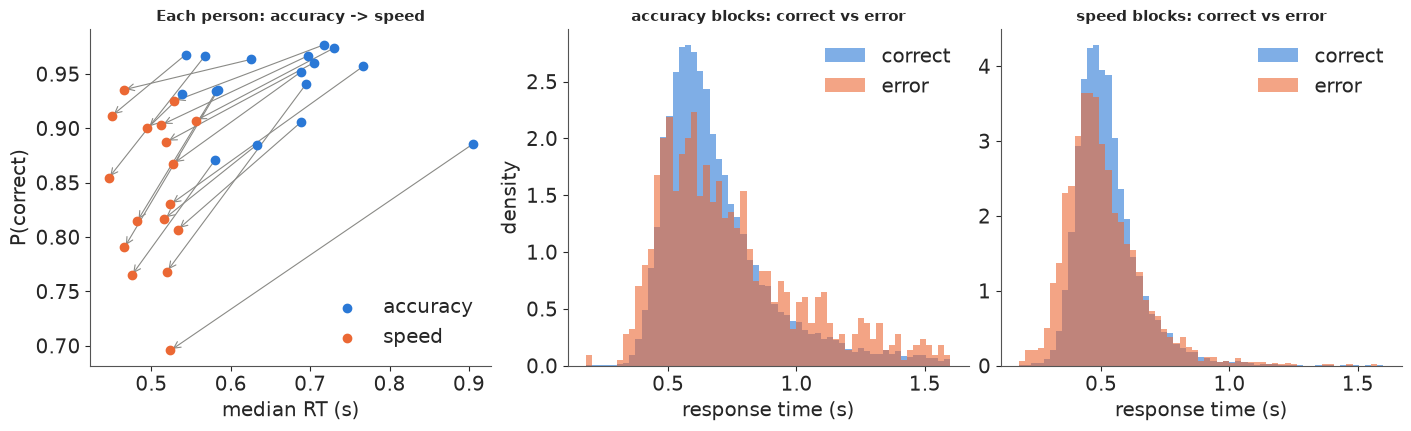

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
per = df.groupby(["id", "condition"]).agg(acc=("correct", "mean"), rt=("rt", "median")).unstack()
for pid in per.index:
    axes[0].annotate("", xy=(per.loc[pid, ("rt", "speed")], per.loc[pid, ("acc", "speed")]),
                     xytext=(per.loc[pid, ("rt", "accuracy")], per.loc[pid, ("acc", "accuracy")]),
                     arrowprops=dict(arrowstyle="->", color=GREY, lw=0.8))
axes[0].scatter(per[("rt", "accuracy")], per[("acc", "accuracy")], color=BLUE, label="accuracy", zorder=3)
axes[0].scatter(per[("rt", "speed")], per[("acc", "speed")], color=ORANGE, label="speed", zorder=3)
axes[0].set(xlabel="median RT (s)", ylabel="P(correct)")
axes[0].set_title("Each person: accuracy -> speed", fontsize=11)
axes[0].legend()
bins = np.linspace(0.18, 1.6, 60)
for ax, cond in zip(axes[1:], ["accuracy", "speed"]):
    sub = df[df.condition == cond]
    ax.hist(sub.rt[sub.correct], bins=bins, density=True, color=BLUE, alpha=0.6, label="correct")
    ax.hist(sub.rt[~sub.correct], bins=bins, density=True, color=ORANGE, alpha=0.6, label="error")
    ax.set(xlabel="response time (s)")
    ax.set_title(f"{cond} blocks: correct vs error", fontsize=11)
    ax.legend()
axes[1].set_ylabel("density");

The instruction works: every participant is faster and less accurate under speed instructions.
Word frequency matters for words (very-low-frequency words are the hardest) and hardly at all
for nonwords. And the last column of the table shows the pattern a model must reproduce. Under
**speed** instructions errors are **faster** than correct responses in every class (by 12-48 ms).
Under **accuracy** instructions it depends on the item: errors are **slower** for the hard classes
(very-low-frequency words by 84 ms, two nonword classes by about 40 ms) and faster for the easy
high-frequency words. Recall from part A that a plain DDM with an unbiased start predicts *equal*
time distributions for errors and correct responses.

**The model.** For participant $s$, instruction $c$ and stimulus class $j$:

* threshold $a_{sc} = \exp(\alpha_{sc})$, with $\alpha_{sc} \sim N(\mu_{\alpha c}, \sigma_\alpha)$;
* drift towards the correct answer $v_{sj} \sim N(\mu_{vj}, \sigma_v)$, multiplied by
  $e^{\gamma_s}$ under speed instructions (speed pressure could lower evidence quality; if it
  does not, $\gamma = 0$); the drift towards "word" is $+v$ for words and $-v$ for nonwords;
* non-decision time $t_{0,sc} = \exp(\tau_{sc})$, also by instruction;
* bias $w_s = \text{logit}^{-1}(\omega_s)$;
* all person-level effects non-centred. The *plain* model has no drift or start variability; the
  full model (part D) adds them, one value per instruction.

**Contaminants.** Some responses are not the diffusion process at all. A trial faster than a
participant's $t_0$ has DDM likelihood zero and would pin $t_0$ below it. The data say what these
responses are: responses under 0.3 s are 0.8% of speed-block trials (0.06% of accuracy-block
trials) and only 44% of them are correct - **fast guesses**. Responses slower than 1.5 s, by
contrast, are 86% correct: slow decisions, not guesses. So the contaminant is a fast guess,
uniform on 0.18-0.5 s with either key equally likely, with probability $\pi_c$ per instruction:
$(1 - \pi_c)\, p_{\text{DDM}} + \pi_c\, \frac{\mathbb{1}[t < 0.5]}{2 \times 0.32}$. Because
$p_{\text{DDM}} \to 0$ smoothly as $t \to t_0$, this also removes the hard wall at $t_0$.

*What the obvious alternative did.* A first version used the common choice of contaminants
uniform over the whole 0.18-3 s window. It fitted, but (i) a uniform guess with a random key
puts phantom *slow errors* into every cell where real errors are rare (with 2% contaminants and
1.8% errors for high-frequency words, it predicted errors 300 ms slower than correct responses,
against 58 ms *faster* in the data), and (ii) the non-decision time of two participants mixed
badly (r_hat 1.14, chain means 318-334 ms, zero divergences). With fast guesses both problems
went away. A contaminant is part of the model and deserves the same checks.

**The observation** is a *signed* response time, positive for "word" and negative for
"nonword", so one `pm.CustomDist` carries both the choice and the time, and
`pm.compute_log_likelihood` gives one term per trial for LOO.

**Priors**, in the scaled units of part A: thresholds around 1.2 (0.6-2.6), drifts around 2 with
room for 0 and 5, $t_0$ around 350 ms (200-600 ms), no bias expected, person-to-person
standard deviations of about 30% on the log scale, and a guess rate around 2% (Beta(1, 49)).

**Runtime.** The likelihood costs about 30 transcendental functions per trial. To keep this
notebook under about six minutes we fit a **random quarter of each participant's trials in every
instruction x stimulus cell** (7,800 trials, still ~230 per participant and instruction) and keep
the other three quarters as a **held-out test set** - which gives us a free out-of-sample check.
We sample with PyTensor's JAX backend: one gradient of the full model takes about 1.1 ms with JAX
(which uses two to three cores per call) against 5 ms with the default Numba backend (one core).
nutpie runs JAX chains one after another but Numba chains in parallel, so the wall-clock gain is
smaller than the per-gradient one; numpyro's own sampler with four parallel chains was slower
than either here.

In [9]:
fit_df = df.groupby(["id", "condition", "frequency"]).sample(frac=0.25, random_state=RANDOM_SEED)
hold_df = df.drop(fit_df.index)
fit_df, hold_df = fit_df.reset_index(drop=True), hold_df.reset_index(drop=True)
print(f"fit on {len(fit_df):,} trials, hold out {len(hold_df):,}")

SUBJ = np.sort(df.id.unique())
INSTR = ["accuracy", "speed"]
LO, HI = 0.18, 3.0             # the RT window kept by the authors
GUESS_HI = 0.5                 # fast guesses: uniform on [LO, GUESS_HI], either key
LOG_GUESS = -np.log(2 * (GUESS_HI - LO))


def encode(frame):
    """Integer codes and the signed response time of each trial."""
    stim = pd.Index(STIM).get_indexer(frame["frequency"])
    return dict(subj=pd.Index(SUBJ).get_indexer(frame["id"]),
                speed=(frame["condition"] == "speed").to_numpy().astype(int),
                stim=stim, sign=np.where(stim < 3, 1.0, -1.0),
                y=np.where(frame["upper"], frame["rt"], -frame["rt"]))


def ddm_mixture_logp(y, v, a, w, t0, pc, sv, sz=None):
    """Contaminated DDM log-likelihood of signed response times (contaminant probability pc)."""
    dt = pt.abs(y) - t0
    lp = wfpt_logp(pt.maximum(dt, 1e-4), y > 0, v, a, w, sv, sz)
    lp = pt.switch(dt > 1e-4, lp, -np.inf)
    guess = pt.switch(pt.abs(y) < GUESS_HI, pt.log(pc) + LOG_GUESS, -np.inf)
    return pt.logaddexp(pt.log1p(-pc) + lp, guess)


def mix_np(lp, pc, y):
    return np.logaddexp(np.log1p(-pc) + lp, np.where(np.abs(y) < GUESS_HI, np.log(pc) + LOG_GUESS, -np.inf))


def ddm_model(frame, variability=True):
    e = encode(frame)
    coords = {"subj": SUBJ, "instr": INSTR, "stim": STIM, "trial": np.arange(len(frame))}
    with pm.Model(coords=coords) as m:
        mu_la = pm.Normal("mu_la", np.log(1.2), 0.4, dims="instr")
        sd_la = pm.HalfNormal("sd_la", 0.3)
        a = pm.Deterministic("a", pt.exp(mu_la + sd_la * pm.Normal("z_la", dims=("subj", "instr"))),
                             dims=("subj", "instr"))
        mu_v = pm.Normal("mu_v", 2.0, 1.5, dims="stim")
        sd_v = pm.HalfNormal("sd_v", 1.0)
        v = pm.Deterministic("v", mu_v + sd_v * pm.Normal("z_v", dims=("subj", "stim")), dims=("subj", "stim"))
        mu_g = pm.Normal("mu_g", 0.0, 0.3)
        sd_g = pm.HalfNormal("sd_g", 0.2)
        g = pm.Deterministic("g", mu_g + sd_g * pm.Normal("z_g", dims="subj"), dims="subj")
        mu_lt = pm.Normal("mu_lt", np.log(0.35), 0.3, dims="instr")
        sd_lt = pm.HalfNormal("sd_lt", 0.3)
        t0 = pm.Deterministic("t0", pt.exp(mu_lt + sd_lt * pm.Normal("z_lt", dims=("subj", "instr"))),
                              dims=("subj", "instr"))
        pc = pm.Beta("pc", 1.0, 49.0, dims="instr")   # probability of a fast guess, prior mean 2%
        mu_w = pm.Normal("mu_w", 0.0, 0.5)
        sd_w = pm.HalfNormal("sd_w", 0.5)
        w = pm.Deterministic("w", pm.math.invlogit(mu_w + sd_w * pm.Normal("z_w", dims="subj")), dims="subj")
        if variability:
            sv = pm.HalfNormal("sv", 1.0, dims="instr")
            sz = pm.Beta("sz", 1.5, 4.0, dims="instr")   # start range as a fraction of the widest possible
        else:
            sv, sz = pt.as_tensor(0.0), None
        s, c, j = e["subj"], e["speed"], e["stim"]
        v_i = e["sign"] * v[s, j] * pt.exp(g[s] * c)
        w_i = w[s]
        sz_i = None if sz is None else sz[c] * 2 * pt.minimum(w_i, 1 - w_i)   # stay inside (0, 1)
        sv_i = sv if sz is None else sv[c]
        params = [v_i, a[s, c], w_i, t0[s, c], pc[c], sv_i] + ([] if sz_i is None else [sz_i])
        pm.CustomDist("y", *params, logp=ddm_mixture_logp, observed=e["y"], dims="trial")
    return m

fit on 7,848 trials, hold out 23,503


**Prior predictive check.** The `CustomDist` has no random generator, so we draw the parameters
from the prior and push them through the simulator from part A: one participant, 200 trials of a
low-frequency word under accuracy instructions, per prior draw.

prior predictive: median RT 5-95% = [0.26 1.03] s; P(correct) 5-95% = [0.22 1.  ]; walks unfinished at 6 s: 0.0%


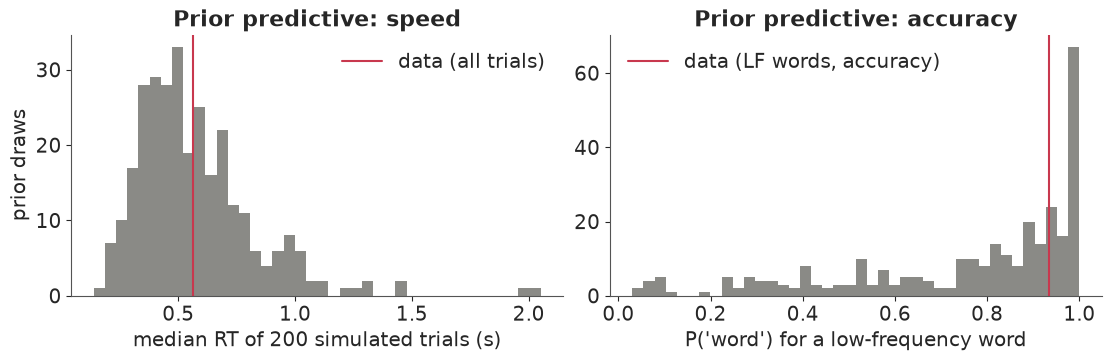

In [10]:
m_full = ddm_model(fit_df)
prior = pm.sample_prior_predictive(draws=300, model=m_full, random_seed=RANDOM_SEED,
                                   var_names=["a", "v", "g", "t0", "w", "sv", "sz"]).prior
pr = {k: prior[k].to_numpy().reshape(300, *prior[k].shape[2:]) for k in ["a", "v", "t0", "w", "sv", "sz"]}
pr["sv"], pr["sz"] = pr["sv"][:, 0], pr["sz"][:, 0]   # accuracy instruction
sim_rng = np.random.default_rng(5)
n_tr = 200
w_pr = pr["w"][:, 0]
rt_pr, up_pr = simulate_ddm(np.repeat(pr["v"][:, 0, 1], n_tr), np.repeat(pr["a"][:, 0, 0], n_tr),
                            np.repeat(w_pr, n_tr), np.repeat(pr["t0"][:, 0, 0], n_tr), 300 * n_tr, sim_rng,
                            sv=np.repeat(pr["sv"], n_tr),
                            sz=np.repeat(pr["sz"] * 2 * np.minimum(w_pr, 1 - w_pr), n_tr))
rt_pr, up_pr = rt_pr.reshape(300, n_tr), up_pr.reshape(300, n_tr)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist(np.nanmedian(rt_pr, axis=1), bins=40, color=GREY)
axes[0].axvline(fit_df.rt.median(), color=RED, label="data (all trials)")
axes[0].set(xlabel="median RT of 200 simulated trials (s)", ylabel="prior draws", title="Prior predictive: speed")
axes[0].legend()
axes[1].hist(up_pr.mean(axis=1), bins=40, color=GREY)
axes[1].axvline(df[(df.condition == "accuracy") & (df.frequency == "low")].correct.mean(), color=RED,
                label="data (LF words, accuracy)")
axes[1].set(xlabel="P('word') for a low-frequency word", title="Prior predictive: accuracy")
axes[1].legend()
print(f"prior predictive: median RT 5-95% = {np.nanquantile(np.nanmedian(rt_pr, 1), [0.05, 0.95]).round(2)} s; "
      f"P(correct) 5-95% = {np.quantile(up_pr.mean(1), [0.05, 0.95]).round(2)}; "
      f"walks unfinished at 6 s: {np.isnan(rt_pr).mean():.1%}");

Wide but sensible: median response times from 0.26 to 1.03 s (5-95%), and accuracy for a
low-frequency word from chance-or-worse to perfect, piled towards high accuracy. The data sit
well inside both. The priors allow fast and sloppy as well as slow and careful behaviour, and put
little weight on absurd response times.

Now the **plain DDM** (no drift or start variability).

In [11]:
def fit(model, label, **kw):
    t_start = time.time()
    idata = pm.sample(model=model, random_seed=RANDOM_SEED, progressbar=False, compile_kwargs=JAX, **kw)
    elapsed = time.time() - t_start
    rhat = az.rhat(idata.posterior).to_dataset().to_dataarray().max().item()
    ess = az.ess(idata.posterior).to_dataset().to_dataarray().min().item()
    print(f"{label}: {elapsed:.0f} s, {int(idata.sample_stats['diverging'].sum())} divergences, "
          f"max r_hat {rhat:.3f}, min bulk ESS {ess:.0f}, "
          f"{idata.posterior.attrs.get('tuning_steps')} tuning steps")
    return idata


m_plain = ddm_model(fit_df, variability=False)
idata_plain = fit(m_plain, "plain DDM")
az.summary(idata_plain, var_names=["mu_la", "mu_v", "mu_g", "mu_lt", "mu_w", "pc"], round_to=3)

plain DDM: 38 s, 0 divergences, max r_hat 1.014, min bulk ESS 264, 400 tuning steps


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu_la[accuracy],0.428,0.033,0.374,0.482,820.543,1141.532,1.003,0.001,0.001
mu_la[speed],0.034,0.032,-0.018,0.085,785.694,967.833,1.008,0.001,0.001
mu_v[high],3.188,0.143,2.961,3.415,2062.466,2159.837,1.002,0.003,0.002
mu_v[low],1.924,0.131,1.717,2.135,1792.531,1866.322,1.002,0.003,0.002
mu_v[very_low],1.246,0.123,1.048,1.447,1898.896,2374.366,1.001,0.003,0.002
mu_v[nw_high],2.117,0.131,1.906,2.326,1431.798,1797.167,1.002,0.003,0.002
mu_v[nw_low],2.056,0.126,1.853,2.253,1721.756,1842.088,1.003,0.003,0.002
mu_v[nw_very_low],2.114,0.132,1.907,2.327,1993.621,2099.541,1.001,0.003,0.002
mu_g,-0.008,0.060,-0.104,0.088,1208.316,1616.555,1.003,0.002,0.001
mu_lt[accuracy],-0.949,0.025,-0.990,-0.911,497.508,868.022,1.014,0.001,0.001


It samples cleanly. Whether it fits is a different question. For each posterior draw we compute
the model's density on a grid of times for every participant x instruction x stimulus cell, then
**pool the cells as the data are pooled** (each participant weighted by their number of trials in
the comparison set) and read off P(correct) and the 10/30/50/70/90% quantiles of correct and error
times. We compare with the **held-out** trials, which the model never saw.

In [12]:
T_GRID = np.linspace(LO, HI, 500)
QS = np.array([0.1, 0.3, 0.5, 0.7, 0.9])


def variability_draws(idata, n_draws, seed):
    """Drift and start variability by instruction, shape (2, n_draws); zeros for the plain model."""
    if "sv" not in idata.posterior:
        return np.zeros((2, n_draws)), np.zeros((2, n_draws))
    return tuple(az.extract(idata, var_names=[k], num_samples=n_draws, random_seed=seed)
                 .transpose("instr", "sample").to_numpy() for k in ("sv", "sz"))


def cell_predictions(idata, frame, n_draws=100, seed=1):
    """Posterior predictive P(correct) and correct/error RT quantiles per (instruction, stimulus),
    pooling participants with the trial counts of `frame`. Returns an xarray Dataset."""
    post = az.extract(idata, var_names=["a", "v", "g", "t0", "w"], num_samples=n_draws, random_seed=seed)
    sv, sz = variability_draws(idata, n_draws, seed)
    pc = az.extract(idata, var_names=["pc"], num_samples=n_draws, random_seed=seed).transpose("instr", "sample").to_numpy()
    counts = (frame.groupby(["condition", "frequency", "id"]).size()
              .reindex(pd.MultiIndex.from_product([INSTR, STIM, SUBJ])).fillna(0).to_numpy().reshape(2, 6, -1))
    S, nT = len(SUBJ), len(T_GRID)
    # every (instr, stim, subj, threshold, time) combination for one draw
    ci, ji, si, ui, ti = np.meshgrid(np.arange(2), np.arange(6), np.arange(S), [0, 1], np.arange(nT), indexing="ij")
    ci, ji, si, ui, ti = (x.ravel() for x in (ci, ji, si, ui, ti))
    sign = np.where(ji < 3, 1.0, -1.0)
    y = np.where(ui == 1, 1.0, -1.0) * T_GRID[ti]
    out = {k: np.empty((n_draws, 2, 6, *s)) for k, s in [("p_correct", ()), ("q_correct", (5,)), ("q_error", (5,))]}
    a_, v_, g_, t0_, w_ = (post[k].transpose(..., "sample").to_numpy() for k in ["a", "v", "g", "t0", "w"])
    for d in range(n_draws):
        vi = sign * v_[si, ji, d] * np.exp(g_[si, d] * ci)
        wi = w_[si, d]
        lp = ddm_logpdf(y, vi, a_[si, ci, d], wi, t0_[si, ci, d], sv[ci, d], sz[ci, d] * 2 * np.minimum(wi, 1 - wi))
        dens = np.exp(mix_np(lp, pc[ci, d], y)).reshape(2, 6, S, 2, nT)
        pooled = np.einsum("cjsut,cjs->cjut", dens, counts) / counts.sum(-1)[..., None, None]
        cdf = np.cumsum(pooled, axis=-1) * (T_GRID[1] - T_GRID[0])
        for c in range(2):
            for j in range(6):
                up_is_correct = j < 3
                corr, err = (cdf[c, j, 1], cdf[c, j, 0]) if up_is_correct else (cdf[c, j, 0], cdf[c, j, 1])
                out["p_correct"][d, c, j] = corr[-1] / (corr[-1] + err[-1])
                out["q_correct"][d, c, j] = np.interp(QS * corr[-1], corr, T_GRID)
                out["q_error"][d, c, j] = np.interp(QS * err[-1], err, T_GRID)
    dims = {"p_correct": ("draw", "instr", "stim"), "q_correct": ("draw", "instr", "stim", "q"),
            "q_error": ("draw", "instr", "stim", "q")}
    return xr.Dataset({k: (dims[k], val) for k, val in out.items()},
                      coords={"instr": INSTR, "stim": STIM, "q": QS})


def observed_summary(frame):
    rows = {}
    for (c, j), g in frame.groupby(["condition", "frequency"]):
        rows[(c, j)] = (g.correct.mean(), np.quantile(g.rt[g.correct], QS), np.quantile(g.rt[~g.correct], QS))
    return xr.Dataset({
        "p_correct": (("instr", "stim"), [[rows[c, j][0] for j in STIM] for c in INSTR]),
        "q_correct": (("instr", "stim", "q"), [[rows[c, j][1] for j in STIM] for c in INSTR]),
        "q_error": (("instr", "stim", "q"), [[rows[c, j][2] for j in STIM] for c in INSTR])},
        coords={"instr": INSTR, "stim": STIM, "q": QS})


obs_hold = observed_summary(hold_df)
pred_plain = cell_predictions(idata_plain, hold_df)
diff_obs = 1000 * (obs_hold.q_error - obs_hold.q_correct).sel(q=0.5)
diff_plain = 1000 * (pred_plain.q_error - pred_plain.q_correct).sel(q=0.5)
print("median error RT - median correct RT (ms), held-out trials")
print(pd.DataFrame({"observed": diff_obs.to_series(),
                    "plain DDM": diff_plain.median("draw").to_series()}).unstack(0).round(0))

median error RT - median correct RT (ms), held-out trials
            observed       plain DDM      
instr       accuracy speed  accuracy speed
stim                                      
high           -58.0 -50.0    -100.0 -27.0
low              8.0 -34.0     -26.0 -15.0
very_low        82.0 -29.0       8.0 -10.0
nw_high         -4.0 -34.0     -46.0 -25.0
nw_low          56.0 -14.0     -42.0 -26.0
nw_very_low     42.0 -13.0     -47.0 -25.0


The plain DDM predicts errors *faster* than correct responses in all twelve cells. Its own errors
have the same time distribution as its correct responses (part A), so the only thing that can
separate them is the fast guesses, which are half errors. The data have **slow** errors for the
hard classes under accuracy instructions (very-low-frequency words 82 ms, low-frequency nonwords
56 ms on these held-out trials), and the plain model puts them at 8 and -42 ms. This is not a
problem that more data or better sampling fixes: the model **cannot** produce slow errors. It is
the observation that led Ratcliff to add across-trial variability.

## D. Drift and starting-point variability

Why do these help? With **drift variability**, errors come mostly from trials whose drift
happened to be low, and low-drift trials are slow: errors become slower than correct responses.
With **starting-point variability**, errors come mostly from trials that started close to the
wrong threshold, and those end quickly: errors become fast. Low thresholds (speed instructions)
make the start matter more, high thresholds (accuracy) make the drift matter more - the
crossover in the data. Because the instructions may change both, the full model has one $s_v$
and one $s_z$ per instruction (priors HalfNormal(1) and Beta(1.5, 4); the likelihood cost is
unchanged).

In [13]:
idata_full = fit(m_full, "full DDM (sv, sz)")
# where is the worst r_hat? (per-chain means of the least well mixed non-decision time)
rh_t0 = az.rhat(idata_full.posterior["t0"])
worst = rh_t0.to_series().idxmax()
print(f"worst r_hat: t0 of participant {worst[0]}, {worst[1]} instruction ({rh_t0.max().item():.3f}); "
      f"chain means (ms): {(1000 * idata_full.posterior['t0'].sel(subj=worst[0], instr=worst[1]).mean('draw')).to_numpy().round(1)}; "
      f"fastest RTs in that cell (fitted): {np.sort(fit_df.rt[(fit_df.id == worst[0]) & (fit_df.condition == worst[1])])[:5]}")
az.summary(idata_full, var_names=["mu_la", "mu_v", "mu_g", "mu_lt", "mu_w", "pc", "sv", "sz",
                                  "sd_la", "sd_v", "sd_g", "sd_lt", "sd_w"], round_to=3)

full DDM (sv, sz): 153 s, 0 divergences, max r_hat 1.010, min bulk ESS 306, 400 tuning steps
worst r_hat: t0 of participant 3, accuracy instruction (1.003); chain means (ms): [439.4 439.3 439.2 438.4]; fastest RTs in that cell (fitted): [0.187 0.187 0.392 0.398 0.424]


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu_la[accuracy],0.528,0.039,0.467,0.590,1151.558,1509.744,1.002,0.001,0.001
mu_la[speed],0.056,0.036,-0.002,0.116,969.666,1364.394,1.003,0.001,0.001
mu_v[high],4.038,0.190,3.741,4.343,1793.833,2320.022,1.001,0.004,0.003
mu_v[low],2.462,0.158,2.208,2.717,2090.235,2588.100,1.002,0.003,0.003
mu_v[very_low],1.617,0.149,1.379,1.857,2168.465,2213.863,1.002,0.003,0.002
mu_v[nw_high],2.694,0.163,2.436,2.963,1788.658,2284.168,1.001,0.004,0.002
mu_v[nw_low],2.643,0.162,2.387,2.904,2006.322,2139.149,1.002,0.004,0.003
mu_v[nw_very_low],2.713,0.161,2.461,2.978,2074.602,2314.077,1.000,0.004,0.003
mu_g,-0.167,0.069,-0.277,-0.058,1387.899,1507.445,1.002,0.002,0.001
mu_lt[accuracy],-0.922,0.025,-0.961,-0.882,579.930,920.532,1.005,0.001,0.001


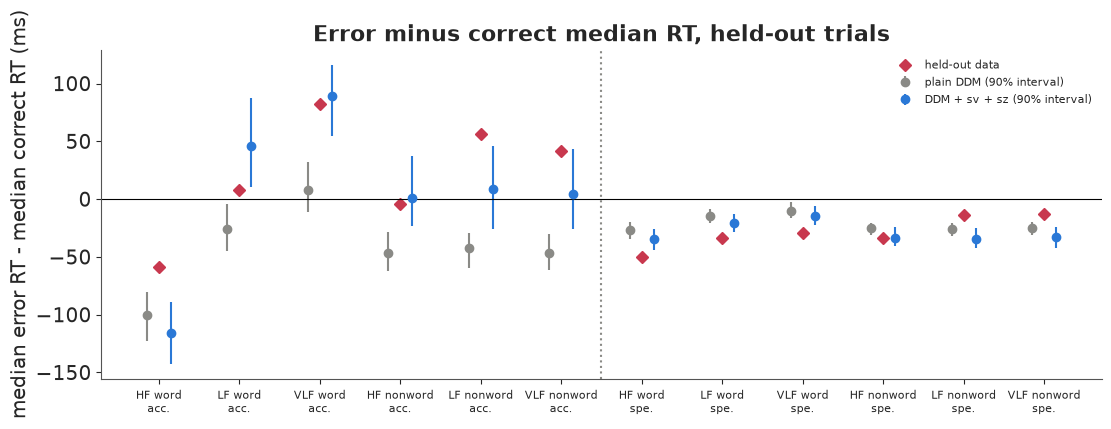

In [14]:
pred_full = cell_predictions(idata_full, hold_df)
diff_full = 1000 * (pred_full.q_error - pred_full.q_correct).sel(q=0.5)
fig, ax = plt.subplots(figsize=(11, 4))
xpos = np.arange(12)
labels = [f"{s}\n{c[:3]}." for c in INSTR for s in STIM_LABEL]
for off, pred, col, lab in [(-0.15, diff_plain, GREY, "plain DDM"), (0.15, diff_full, BLUE, "DDM + sv + sz")]:
    lo, med, hi = (pred.quantile(q, "draw").to_numpy().ravel() for q in (0.05, 0.5, 0.95))
    ax.errorbar(xpos + off, med, yerr=[med - lo, hi - med], fmt="o", color=col, label=f"{lab} (90% interval)")
ax.plot(xpos, diff_obs.to_numpy().ravel(), "D", color=RED, label="held-out data")
ax.axhline(0, color="k", lw=0.8)
ax.axvline(5.5, color=GREY, ls=":")
ax.set_xticks(xpos, labels, fontsize=8)
ax.set(ylabel="median error RT - median correct RT (ms)",
       title="Error minus correct median RT, held-out trials")
ax.legend(fontsize=8);

A fuller check is Ratcliff's **quantile-probability plot**: for each stimulus class, the five
response-time quantiles are drawn above the probability of that response - correct responses on
the right of 0.5, errors on the left. One picture shows accuracy, the shape of both time
distributions, and how they move together across conditions.

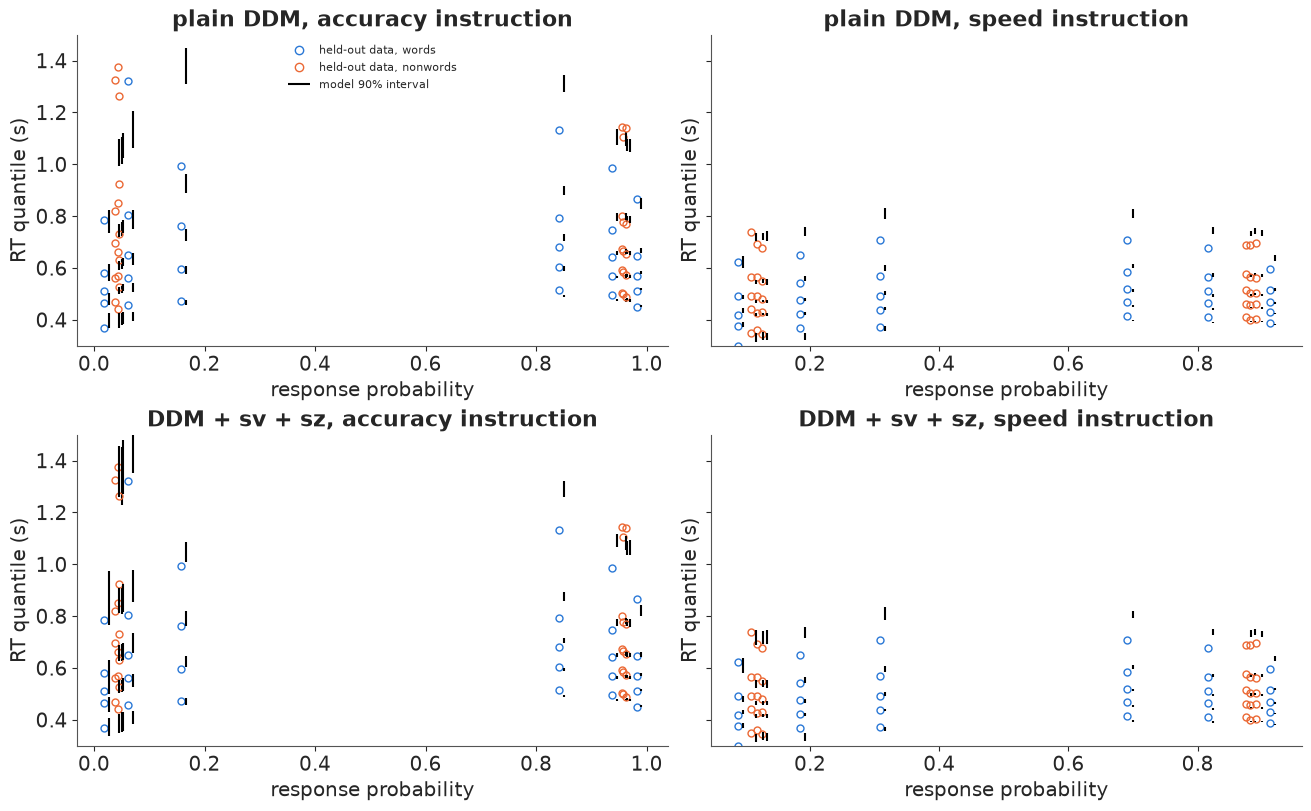

In [15]:
def qp_plot(ax, pred, obs, instr, title):
    for j, stim in enumerate(STIM):
        col = BLUE if j < 3 else ORANGE
        p_obs = obs.p_correct.sel(instr=instr, stim=stim).item()
        for p, qo, qp_ in [(p_obs, obs.q_correct, pred.q_correct), (1 - p_obs, obs.q_error, pred.q_error)]:
            ax.plot(np.full(5, p), qo.sel(instr=instr, stim=stim), "o", mfc="none", color=col, ms=5)
            pp = qp_.sel(instr=instr, stim=stim)
            ax.vlines(np.full(5, p) + 0.008, pp.quantile(0.05, "draw"), pp.quantile(0.95, "draw"), color="k", lw=1.5)
    ax.set(xlabel="response probability", ylabel="RT quantile (s)", title=title, ylim=(0.3, 1.5))


fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharey=True)
for col, instr in enumerate(INSTR):
    qp_plot(axes[0, col], pred_plain, obs_hold, instr, f"plain DDM, {instr} instruction")
    qp_plot(axes[1, col], pred_full, obs_hold, instr, f"DDM + sv + sz, {instr} instruction")
axes[0, 0].plot([], [], "o", mfc="none", color=BLUE, label="held-out data, words")
axes[0, 0].plot([], [], "o", mfc="none", color=ORANGE, label="held-out data, nonwords")
axes[0, 0].vlines([], [], [], color="k", label="model 90% interval")
axes[0, 0].legend(fontsize=8, loc="upper center");

Read each column of circles as one response type in one condition: correct responses on the
right, errors on the left; the bars are the model's 90% intervals at the same probability.
Both models place the correct-response quantiles well. The difference is on the left, in the
accuracy blocks: the plain model's error quantiles are too fast in the upper half, while the
variability model reaches the slow errors (0.7 and 0.9 quantiles of 1.1-1.4 s). Two misfits
remain, visible in the previous figure: the model makes high-frequency-word errors under accuracy
too fast (-116 vs -58 ms; only 47 such errors in the whole data set), and makes nonword errors
under accuracy barely slower than correct responses where the data have them 40-55 ms slower.
The full model allows one drift variability per instruction, not per stimulus class, and that is
a candidate cause.

**Model comparison.** PSIS-LOO on the fitted trials, and the log predictive density of the
23,000 held-out trials (averaging the likelihood over posterior draws for each trial).

In [16]:
def loo_of(model, idata):
    thin = idata.isel(draw=slice(None, None, 2))
    pm.compute_log_likelihood(thin, model=model, progressbar=False)
    res = az.loo(thin, pointwise=True)
    res.log_weights = None
    return res


def heldout_lpd(idata, frame, n_draws=400, seed=2, fn=ddm_logpdf):
    """Per-trial log mean predictive density of held-out trials."""
    post = az.extract(idata, var_names=["a", "v", "g", "t0", "w"], num_samples=n_draws, random_seed=seed)
    sv, sz = variability_draws(idata, n_draws, seed)
    pc = az.extract(idata, var_names=["pc"], num_samples=n_draws, random_seed=seed).transpose("instr", "sample").to_numpy()
    a_, v_, g_, t0_, w_ = (post[k].transpose(..., "sample").to_numpy() for k in ["a", "v", "g", "t0", "w"])
    e = encode(frame)
    s, c, j = e["subj"], e["speed"], e["stim"]
    ll = np.empty((n_draws, len(frame)))
    for d in range(n_draws):
        vi = e["sign"] * v_[s, j, d] * np.exp(g_[s, d] * c)
        wi = w_[s, d]
        lp = fn(e["y"], vi, a_[s, c, d], wi, t0_[s, c, d], sv[c, d], sz[c, d] * 2 * np.minimum(wi, 1 - wi))
        ll[d] = mix_np(lp, pc[c, d], e["y"])
    return special.logsumexp(ll, axis=0) - np.log(n_draws)


# the quadrature check promised in part B, at posterior draws, on the fitted trials
ll3, ll40 = (heldout_lpd(idata_full, fit_df, n_draws=40, fn=f) for f in (ddm_logpdf, ddm_logpdf40))
print(f"fitted trials, log-likelihood with 3 vs 40 start nodes: total difference {ll3.sum() - ll40.sum():.2f} "
      f"nats over {len(fit_df):,} trials (largest single trial {np.max(np.abs(ll3 - ll40)):.3f}); "
      f"posterior sz 90% interval by instruction {idata_full.posterior['sz'].quantile([0.05, 0.95], ('chain', 'draw')).to_numpy().T.round(2).tolist()}")

loos = {"plain DDM": loo_of(m_plain, idata_plain), "DDM + sv + sz": loo_of(m_full, idata_full)}
print(az.compare(loos, round_to=1))
lpd_plain, lpd_full = heldout_lpd(idata_plain, hold_df), heldout_lpd(idata_full, hold_df)
dlp = lpd_full - lpd_plain
print(f"held-out: log score plain {lpd_plain.sum():.0f}, full {lpd_full.sum():.0f}; "
      f"difference {dlp.sum():.0f} +- {dlp.std() * np.sqrt(dlp.size):.0f} (paired SE) over {dlp.size:,} trials")
print(f"Pareto k > 0.7: plain {np.sum(loos['plain DDM'].pareto_k.to_numpy() > 0.7)}, "
      f"full {np.sum(loos['DDM + sv + sz'].pareto_k.to_numpy() > 0.7)}")
# how much DDM mass falls outside the 0.18-3 s window the authors kept? (population medians,
# low-frequency words, accuracy instruction; the window's lower edge is below every t0)
pm_ = {k: idata_full.posterior[k].sel(instr="accuracy").median().item() for k in ["sv", "sz"]}
par = dict(v=idata_full.posterior["mu_v"].sel(stim="low").median().item(),
           a=np.exp(idata_full.posterior["mu_la"].sel(instr="accuracy").median().item()),
           t0=np.exp(idata_full.posterior["mu_lt"].sel(instr="accuracy").median().item()))
t_long = np.linspace(1e-4, 20, 200_001)
inside = sum(np.trapezoid(density(t_long[t_long + par["t0"] <= HI], up, par["v"], par["a"], 0.5, pm_["sv"],
                                  pm_["sz"]), t_long[t_long + par["t0"] <= HI]) for up in (True, False))
print(f"DDM mass above 3 s for a typical accuracy-block cell (LF words): {1 - inside:.4f}")

fitted trials, log-likelihood with 3 vs 40 start nodes: total difference -0.18 nats over 7,848 trials (largest single trial 0.027); posterior sz 90% interval by instruction [[0.26, 0.4], [0.29, 0.44]]


/Users/redam94/Coding/coding_challenge/.venv/lib/python3.12/site-packages/arviz_stats/loo/loo_helper.py:1170: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


/Users/redam94/Coding/coding_challenge/.venv/lib/python3.12/site-packages/arviz_stats/loo/loo_helper.py:1170: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


               rank  elpd_diff   dse  p_worse diag_diff     diag_elpd      p    elpd     se  weight
DDM + sv + sz     0        0.0   0.0      NaN            15 k̂ > 0.70  217.1  1765.0  114.8     1.0
plain DDM         1      -57.4  11.6      1.0            10 k̂ > 0.70  231.8  1707.6  116.4     0.0


held-out: log score plain 5144, full 5284; difference 140 +- 19 (paired SE) over 23,503 trials
Pareto k > 0.7: plain 10, full 15
DDM mass above 3 s for a typical accuracy-block cell (LF words): 0.0009


Everything agrees. The 3-node start quadrature costs 0.2 nats over 7,848 trials against 40
nodes at the posterior's $s_z$ (0.26-0.44), so the problem test 4 found does not arise here. LOO
prefers the variability model by about 57 nats (SE 12), and on the 23,503 held-out trials its log
score is higher by 140 (paired SE 19). About 10-15 trials per model have Pareto $\hat k > 0.7$
(out of 7,848), too few to change the ranking.

One modelling caveat worth knowing: the authors dropped trials outside 0.18-3 s, so strictly
the likelihood should be truncated to that window. The model puts no DDM mass below 0.18 s
(every $t_0$ is above 0.25 s) and, as printed, about 0.1% above 3 s, so we ignore the
truncation.

## E. What does "be fast" change?

Instructions are meant to change *caution*, the threshold $a$, and nothing else. This is called
**selective influence**. But the model lets speed pressure change $t_0$ (faster motor responses)
and scale the drift (less careful processing) as well, and the data can say whether they do.

population threshold ratio speed/accuracy: 0.623 (90% interval 0.572 to 0.682)
population t0 change (ms): -41.370 (90% interval -64.330 to -19.509)
population drift factor under speed: 0.846 (90% interval 0.755 to 0.948)
P(threshold lower under speed) = 1.000; P(t0 shorter) = 0.999; P(drift lower) = 0.989


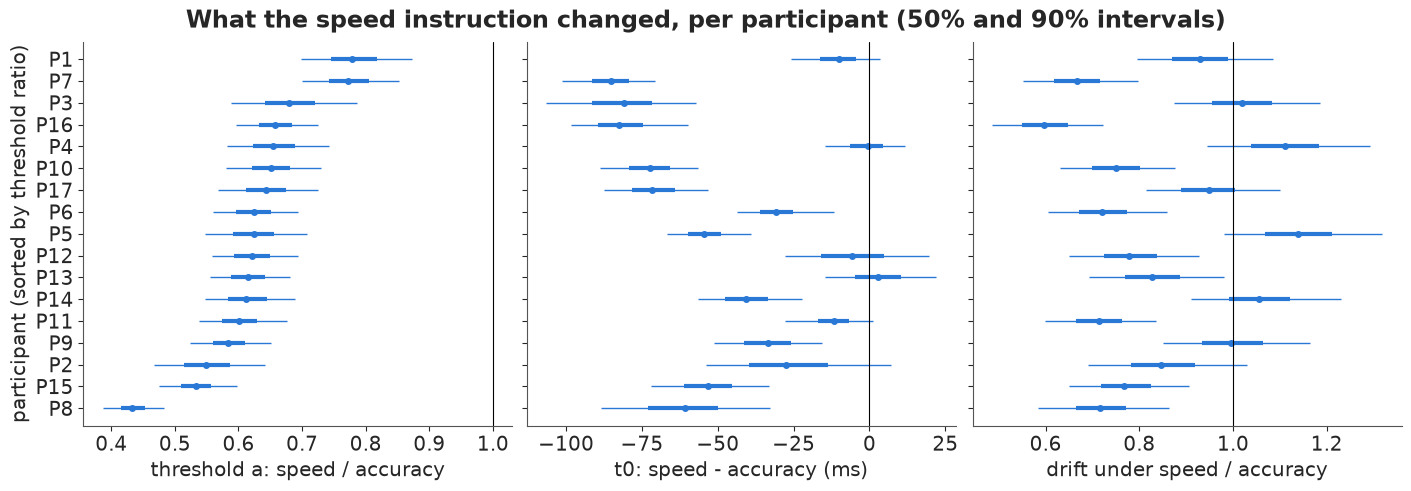

In [17]:
post = idata_full.posterior
a_ratio = post["a"].sel(instr="speed") / post["a"].sel(instr="accuracy")
t0_diff = 1000 * (post["t0"].sel(instr="speed") - post["t0"].sel(instr="accuracy"))
drift_f = np.exp(post["g"])
pop = {
    "threshold ratio speed/accuracy": np.exp(post["mu_la"].sel(instr="speed") - post["mu_la"].sel(instr="accuracy")),
    "t0 change (ms)": 1000 * (np.exp(post["mu_lt"].sel(instr="speed")) - np.exp(post["mu_lt"].sel(instr="accuracy"))),
    "drift factor under speed": np.exp(post["mu_g"]),
}
for k, x in pop.items():
    q = x.quantile([0.05, 0.5, 0.95], ("chain", "draw")).to_numpy()
    print(f"population {k}: {q[1]:.3f} (90% interval {q[0]:.3f} to {q[2]:.3f})")
print(f"P(threshold lower under speed) = {(pop['threshold ratio speed/accuracy'] < 1).mean().item():.3f}; "
      f"P(t0 shorter) = {(pop['t0 change (ms)'] < 0).mean().item():.3f}; "
      f"P(drift lower) = {(pop['drift factor under speed'] < 1).mean().item():.3f}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4.8), sharey=True)
order = np.argsort(a_ratio.median(("chain", "draw")).to_numpy())
for ax, x, ref, lab in [(axes[0], a_ratio, 1, "threshold a: speed / accuracy"),
                        (axes[1], t0_diff, 0, "t0: speed - accuracy (ms)"),
                        (axes[2], drift_f, 1, "drift under speed / accuracy")]:
    q = x.quantile([0.05, 0.25, 0.5, 0.75, 0.95], ("chain", "draw")).to_numpy()[:, order]
    yy = np.arange(len(SUBJ))
    ax.hlines(yy, q[0], q[4], color=BLUE, lw=1)
    ax.hlines(yy, q[1], q[3], color=BLUE, lw=3)
    ax.plot(q[2], yy, "o", color=BLUE, ms=4)
    ax.axvline(ref, color="k", lw=0.8)
    ax.set(xlabel=lab)
axes[0].set_yticks(np.arange(len(SUBJ)), [f"P{p}" for p in SUBJ[order]])
axes[0].set_ylabel("participant (sorted by threshold ratio)")
fig.suptitle("What the speed instruction changed, per participant (50% and 90% intervals)");

The speed instruction lowers every participant's threshold, as intended: to about 62% of its
accuracy-block value (90% interval 57-68%). It also shortens the non-decision time by about
40 ms (20-64 ms), so the pressure is felt in the motor response as well as in the decision. And
it lowers the drift, by about 15% on average (P = 0.99), though participants differ: some keep
their evidence quality, others lose 30-40%. So selective influence fails in these data, as Rae
et al. (2014) reported for this and similar experiments. A model that let the instruction change
only $a$ would have to put the whole speed-up into caution. (Fitting that restricted model and
comparing it by LOO is exercise 1.)

One more reason to take the variability model seriously: the drift effect depends on it. The
plain DDM puts the population drift factor at 0.99 (its `mu_g` is -0.01 +- 0.06), because
without drift variability it has no other way to fit the accuracy blocks' slow errors.

## F. Which threshold should each person use?

Treat the task as a job: every correct answer earns one point, errors earn nothing, and the
participant wants as many points per minute as possible. With $D$ seconds between a response and
the next stimulus and an extra $D_e$ seconds of penalty after an error, the **reward rate** of a
threshold $a$ is (Bogacz et al. 2006)

$$RR(a) = \frac{P_c(a)}{E[DT](a) + t_0 + D + D_e\,(1 - P_c(a))}.$$

A higher threshold raises $P_c$ but spends more time per trial; the best threshold $a^*$
balances them. We compute it for an **ideal observer with each participant's evidence**: their
accuracy-block drifts for the six stimulus classes (all equally common, and the threshold must be
chosen before knowing which one appears), their drift variability, and their accuracy-block
$t_0$; an unbiased start and no start variability (both only cost reward). $P_c$ and $E[DT]$ come
from the closed forms of part A averaged over drift variability by Gauss-Hermite quadrature.

$D$ is an **assumption**: we could not find the exact inter-trial timing of the experiment, so we
use $D = 1$ s and show how the answer moves with it. The speed instruction's other effects
(shorter $t_0$, lower drift) are held out of the comparison: here the only lever is the threshold.

In [18]:
GH_X, GH_W = np.polynomial.hermite_e.hermegauss(20)
GH_W = GH_W / GH_W.sum()
A_GRID = np.linspace(0.3, 3.0, 271)          # steps of 0.01


def reward_rate(a, v, sv, t0, D=1.0, D_err=0.0):
    """Ideal-observer reward rate. a: (..., A); v: (..., J) drifts of equally likely stimulus classes;
    sv, t0: (...,). Returns RR, P(correct) and mean decision time with shape (..., A)."""
    vv = v[..., None, :, None] + sv[..., None, None, None] * GH_X      # (..., 1, J, nodes)
    aa = a[..., :, None, None]
    pc_, dt_ = tradeoff(vv, aa)
    pc = (pc_ * GH_W).sum(-1).mean(-1)
    dt_mean = (dt_ * GH_W).sum(-1).mean(-1)
    return pc / (dt_mean + t0[..., None] + D + D_err * (1 - pc)), pc, dt_mean


ext = az.extract(idata_full, var_names=["v", "t0", "a", "sv"], num_samples=400, random_seed=3)
v_d = ext["v"].transpose("sample", "subj", "stim").to_numpy()
t0_acc = ext["t0"].sel(instr="accuracy").transpose("sample", "subj").to_numpy()
a_d = ext["a"].transpose("sample", "subj", "instr").to_numpy()
sv_d = np.broadcast_to(ext["sv"].sel(instr="accuracy").to_numpy()[:, None], t0_acc.shape)


def rr_analysis(D=1.0, D_err=0.0):
    # one participant at a time: (draws x thresholds x stimuli x nodes) is ~60 MB each
    rr_grid = np.stack([reward_rate(np.broadcast_to(A_GRID, (len(t0_acc), A_GRID.size)), v_d[:, s], sv_d[:, s],
                                    t0_acc[:, s], D, D_err)[0] for s in range(len(SUBJ))], axis=1)
    rr_at = {c: reward_rate(a_d[..., i:i + 1], v_d, sv_d, t0_acc, D, D_err)[0][..., 0] for i, c in enumerate(INSTR)}
    a_star = A_GRID[rr_grid.argmax(-1)]                          # (sample, subj)
    return rr_grid, rr_at, a_star


rr_grid, rr_at, a_star = rr_analysis()
eff = {c: rr_at[c] / rr_grid.max(-1) for c in INSTR}
tab = pd.DataFrame({
    "a* (median)": np.median(a_star, 0), "a* 5%": np.quantile(a_star, 0.05, 0), "a* 95%": np.quantile(a_star, 0.95, 0),
    "a accuracy": np.median(a_d[..., 0], 0), "a speed": np.median(a_d[..., 1], 0),
    "efficiency accuracy": np.median(eff["accuracy"], 0), "efficiency speed": np.median(eff["speed"], 0),
    "P(accuracy a > a*)": (a_d[..., 0] > a_star).mean(0), "P(speed a < a*)": (a_d[..., 1] < a_star).mean(0),
}, index=[f"P{p}" for p in SUBJ])
print(tab.round(2))
print(f"\nmedian efficiency (reward rate / best possible): accuracy instruction "
      f"{np.median(tab['efficiency accuracy']):.1%}, speed instruction {np.median(tab['efficiency speed']):.1%}")

     a* (median)  a* 5%  a* 95%  a accuracy  a speed  efficiency accuracy  efficiency speed  P(accuracy a > a*)  P(speed a < a*)
P1          0.99   0.97    1.01        1.39     1.08                 0.98              1.00                 1.0             0.03
P2          1.00   0.97    1.03        1.90     1.05                 0.93              1.00                 1.0             0.22
P3          1.02   1.00    1.04        1.87     1.27                 0.94              0.99                 1.0             0.00
P4          0.96   0.94    0.99        1.47     0.97                 0.97              1.00                 1.0             0.48
P5          0.99   0.96    1.01        1.60     1.00                 0.96              1.00                 1.0             0.41
P6          0.99   0.96    1.01        1.50     0.94                 0.97              1.00                 1.0             0.87
P7          0.98   0.95    1.00        1.39     1.07                 0.98              1.00      

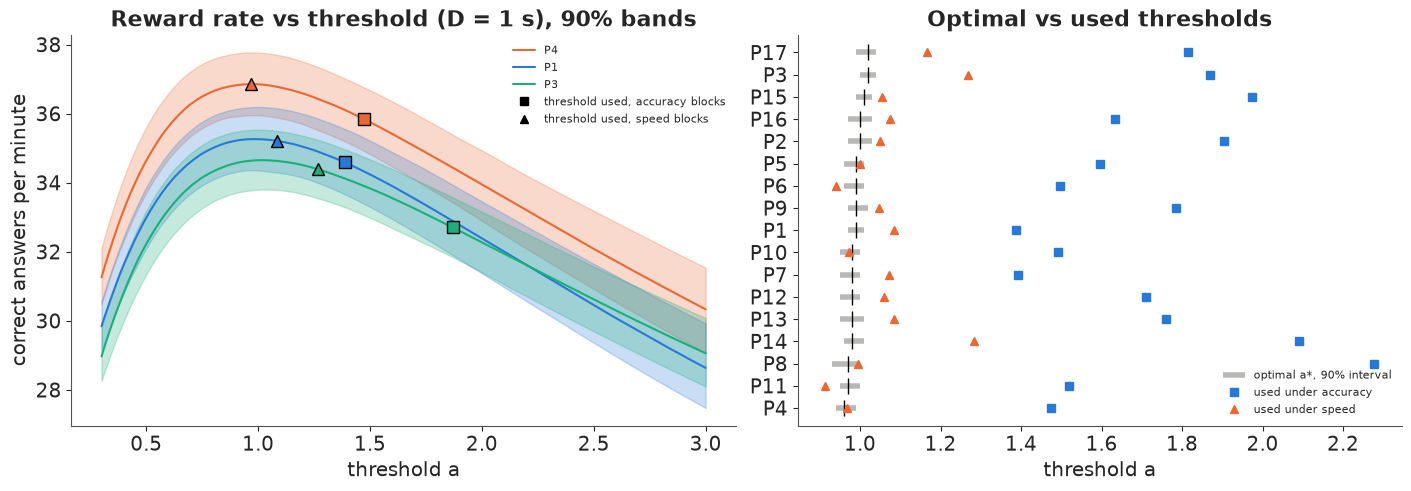

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), width_ratios=[1.1, 1])
examples = [tab["a* (median)"].idxmin(), tab.index[np.argsort(tab["a* (median)"].to_numpy())[len(tab) // 2]],
            tab["a* (median)"].idxmax()]
for pid, col in zip(examples, [ORANGE, BLUE, AQUA]):
    s = list(tab.index).index(pid)
    rr_s = 60 * rr_grid[:, s]                                    # correct answers per minute
    axes[0].fill_between(A_GRID, *np.quantile(rr_s, [0.05, 0.95], 0), color=col, alpha=0.25)
    axes[0].plot(A_GRID, np.median(rr_s, 0), color=col, label=pid)
    for i, mk in enumerate(["s", "^"]):
        a_med = np.median(a_d[:, s, i])
        axes[0].plot(a_med, np.interp(a_med, A_GRID, np.median(rr_s, 0)), mk, color=col, ms=8, mec="k")
axes[0].plot([], [], "sk", label="threshold used, accuracy blocks")
axes[0].plot([], [], "^k", label="threshold used, speed blocks")
axes[0].set(xlabel="threshold a", ylabel="correct answers per minute",
            title="Reward rate vs threshold (D = 1 s), 90% bands")
axes[0].legend(fontsize=8)
yy = np.arange(len(tab))
srt = np.argsort(tab["a* (median)"].to_numpy())
tb = tab.iloc[srt]
axes[1].hlines(yy, tb["a* 5%"], tb["a* 95%"], color=GREY, lw=4, alpha=0.6, label="optimal a*, 90% interval")
axes[1].plot(tb["a* (median)"], yy, "|", color="k", ms=12)
axes[1].plot(tb["a accuracy"], yy, "s", color=BLUE, label="used under accuracy")
axes[1].plot(tb["a speed"], yy, "^", color=ORANGE, label="used under speed")
axes[1].set_yticks(yy, tb.index)
axes[1].set(xlabel="threshold a", title="Optimal vs used thresholds")
axes[1].legend(fontsize=8, loc="lower right");

With $D = 1$ s the optimal threshold is close to 1.0 for everyone (0.96-1.02): the participants'
evidence is similar, and the curve's peak is sharp enough that the posterior pins it within
about $\pm 0.03$. **The thresholds people used under speed instructions are almost exactly
optimal** (99.9% of the best reward rate, median over participants). **Under accuracy
instructions everyone was over-cautious**: thresholds of 1.4-2.3, which give up a median of 5%
of the attainable reward rate (14% for participant 8). This is the pattern Bogacz et al. (2010)
found in their participants too: people lean towards accuracy. Here, though, the accuracy blocks
asked them to.

**How robust is the recommendation?** $D$ was an assumption, so we recompute the population's
median optimum and efficiencies under other inter-trial times and with a 1-second penalty after
errors (a timeout, like the "ERROR" screen).

In [20]:
rows = []
for D, D_err in [(0.5, 0.0), (1.0, 0.0), (2.0, 0.0), (4.0, 0.0), (1.0, 1.0)]:
    g_, at_, astar_ = rr_analysis(D, D_err)
    rows.append((D, D_err, np.median(astar_), np.median(np.median(a_d[..., 0], 0)), np.median(np.median(a_d[..., 1], 0)),
                 np.median(np.median(at_["accuracy"] / g_.max(-1), 0)), np.median(np.median(at_["speed"] / g_.max(-1), 0)),
                 np.mean(np.median(a_d[..., 0], 0) > np.median(astar_, 0))))
print(pd.DataFrame(rows, columns=["D (s)", "error penalty (s)", "median a*", "median a (accuracy)",
                                  "median a (speed)", "efficiency accuracy", "efficiency speed",
                                  "share over-cautious in accuracy blocks"]).round(3))

   D (s)  error penalty (s)  median a*  median a (accuracy)  median a (speed)  efficiency accuracy  efficiency speed  share over-cautious in accuracy blocks
0    0.5                0.0       0.81                1.711             1.054                0.898             0.989                                   1.000
1    1.0                0.0       0.99                1.711             1.054                0.946             0.999                                   1.000
2    2.0                0.0       1.23                1.711             1.054                0.984             0.997                                   1.000
3    4.0                0.0       1.53                1.711             1.054                0.998             0.983                                   0.765
4    1.0                1.0       1.23                1.711             1.054                0.975             0.995                                   1.000


The conclusion depends on $D$, which is itself the lesson. When little time separates trials
($D \le 1$ s), time spent deciding is the main cost, the optimum is low, and the speed blocks are
right. When 4 s separate trials, each trial is expensive, so being right matters more: the
optimum rises to about 1.5, the accuracy blocks become nearly optimal (99.8%), and the speed
blocks fall to 98%. An error timeout works the same way as a longer $D$. **Neither instruction
is "correct" in general: which one is optimal depends on the timing of the task**, and a real
recommendation needs the real inter-trial interval.

**Deciding under uncertainty.** If we had to give one participant a single target threshold, the
Bayes decision maximises the *posterior expected* reward rate, which is not the same as the
optimum at the posterior-mean parameters (the plug-in answer). Because the reward-rate curve is
asymmetric - too low a threshold loses more than too high - the two can differ.

In [21]:
exp_rr = rr_grid.mean(0)                                  # (subj, A): posterior expected reward rate
a_bayes = A_GRID[exp_rr.argmax(-1)]
rr_plug, *_ = reward_rate(np.broadcast_to(A_GRID, (len(SUBJ), A_GRID.size)), v_d.mean(0), sv_d.mean(0), t0_acc.mean(0))
a_plug = A_GRID[rr_plug.argmax(-1)]
loss_plug = 1 - exp_rr[np.arange(len(SUBJ)), rr_plug.argmax(-1)] / exp_rr.max(-1)
print(pd.DataFrame({"Bayes a": a_bayes, "plug-in a": a_plug, "expected loss of plug-in (%)": 100 * loss_plug},
                   index=[f"P{p}" for p in SUBJ]).round(3).T)

                                P1     P2    P3    P4    P5    P6    P7    P8    P9   P10   P11   P12   P13   P14   P15  P16   P17
Bayes a                       0.99  1.000  1.02  0.96  0.99  0.99  0.98  0.97  0.99  0.97  0.97  0.98  0.98  0.98  1.01  1.0  1.02
plug-in a                     0.99  1.010  1.02  0.97  0.99  0.99  0.98  0.97  1.00  0.98  0.98  0.98  0.98  0.99  1.01  1.0  1.02
expected loss of plug-in (%)  0.00  0.002  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.00  0.0  0.00


Here they do not, in any way that matters: the two answers differ by at most 0.01 and the plug-in
choice loses less than 0.01% of the expected reward rate. The posterior is narrow where the
decision is made, so the plug-in answer is safe. With fewer trials per person (exercise 3's data,
or a clinical setting with 50 trials), the same comparison would be worth redoing.

## Summary

* **The model.** A drift diffusion model turns one choice and its time into four interpretable
  quantities: evidence quality, caution, bias and non-decision time. It is also the optimal
  sequential test, which makes "what should this person do?" a question we can answer.
* **The likelihood.** The Wiener first-passage density is two series; a fixed small number of
  terms, a clipped switch between them, a closed-form drift-variability integral and 3-point
  quadrature for the start give a fast, differentiable density - after six tests.
* **The contaminant is part of the model.** A uniform "anything goes" contaminant produced phantom
  slow errors and a badly mixing $t_0$. Looking at the data first (fast responses are chance-level
  guesses, slow ones are real decisions) gave a fast-guess component that fixed both.
* **The failure.** A plain DDM gives errors and correct responses the same time distribution, so
  (with guesses) its errors can only be fast. The data have slow errors for hard items when
  careful; drift variability produces them, start variability keeps errors fast under speed, and
  held-out quantile-probability plots, LOO (+57) and held-out log scores (+140) agree. Nonword
  errors under accuracy remain too fast.
* **Selective influence fails.** "Be fast" lowered the threshold to about 62%, but also shortened
  non-decision time by about 40 ms and lowered drift by about 15% - and only the variability
  model sees the drift effect.
* **The decision.** With 1 s between trials, the reward-rate-optimal threshold is about 1.0 for
  everyone: the speed blocks were essentially optimal and every participant was over-cautious in
  the accuracy blocks (5% fewer correct answers per minute). With 4 s between trials the
  verdict reverses. The Bayes and plug-in thresholds agree here.

## Try it yourself

1. **Test selective influence directly.** Fit a model in which the instruction changes only $a$
   (one $t_0$ per person, $\gamma = 0$) and compare it with the full model by LOO and by held-out
   log score. Where in the quantile-probability plot does it fail?
2. **Non-decision time variability.** Add $s_t$, a uniform spread of $t_0$ across trials, by a
   second Gauss-Legendre quadrature (over $t_0$). Does it improve the fastest quantiles, and how
   much does it cost per gradient?
3. **Another experiment.** `rtdists` also ships `rr98` (Ratcliff & Rouder 1998): three people,
   brightness discrimination at 33 levels of difficulty, speed vs accuracy, ~8,000 trials each.
   Model the drift as a smooth function of brightness and ask the reward-rate question per level.